# Part III: Build Transformer with PyTorch [25 points]
Implement a Transformer model from scratch using the PyTorch framework. Train the model on a provided dataset, exploring various optimization techniques and hyperparameter tuning to achieve optimal performance.
Every component of the Transformer as defined in the paper is expected to be implemented.
The final model should achieve a test accuracy of greater than 80%.

## Step 1: Data Exploration and Preprocessing

1. Select one dataset from the list above.

2. Data exploration:
   - Read, preprocess, and print the main statistics about the dataset.
   - Use libraries like matplotlib, seaborn, or plotly to create at least 3 informative visualizations that reveal insights about the data and potential anomalies (e.g., polarity distribution, word count distribution, vocabulary size etc).

In [2]:
### ADD YOUR CODE HERE ###
!pip install torchtext
!pip install nltk

!pip install torch==2.2.0 torchtext==0.17.0 --upgrade


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 102.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 28.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.11/dist-package

Dataset Statistics:
Number of samples (rows): 120000
Number of unique classes: 4
Class distribution:
Label
2    30000
3    30000
1    30000
0    30000
Name: count, dtype: int64
Average word count per text: 37.85

Text Length Statistics:
Minimum text length (words): 8
Maximum text length (words): 177
Mean text length (words): 37.85
Standard deviation of text length (words): 10.09


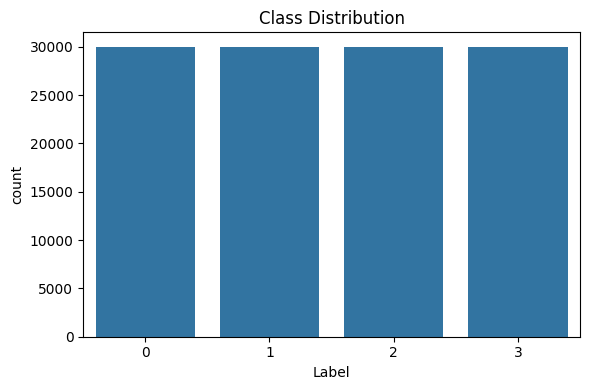

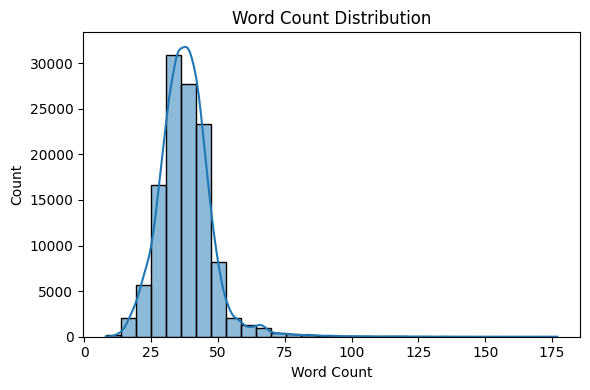

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tarfile
import os
import re
import nltk
import torch
import numpy as np
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from torch.nn.utils.rnn import pad_sequence
from torchtext.vocab import GloVe

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# extract and Load
tar = tarfile.open("ag_news_csv.tar.gz", "r:gz")
tar.extractall("ag_news_data")
tar.close()

df = pd.read_csv("ag_news_data/ag_news_csv/train.csv", header=None, names=["Class", "Title", "Description"])
df["Text"] = df["Title"] + " " + df["Description"]
df.drop(columns=["Title", "Description"], inplace=True)

# label mapping
class_mapping = {1: 0, 2: 1, 3: 2, 4: 3}
df["Label"] = df["Class"].map(class_mapping)

# word count column
df["Word Count"] = df["Text"].apply(lambda x: len(str(x).split()))

# print main statistics about the dataset
print("Dataset Statistics:")
print(f"Number of samples (rows): {df.shape[0]}")
print(f"Number of unique classes: {df['Label'].nunique()}")
print(f"Class distribution:\n{df['Label'].value_counts()}")
print(f"Average word count per text: {df['Word Count'].mean():.2f}")

# text length info
min_length = df["Word Count"].min()
max_length = df["Word Count"].max()
mean_length = df["Word Count"].mean()
std_length = df["Word Count"].std()

print("\nText Length Statistics:")
print(f"Minimum text length (words): {min_length}")
print(f"Maximum text length (words): {max_length}")
print(f"Mean text length (words): {mean_length:.2f}")
print(f"Standard deviation of text length (words): {std_length:.2f}")

# visualization 1: class distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Label", data=df)
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

# visualization 2: word count distribution
df["Word Count"] = df["Text"].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(6,4))
sns.histplot(df["Word Count"], bins=30, kde=True)
plt.title("Word Count Distribution")
plt.tight_layout()
plt.show()

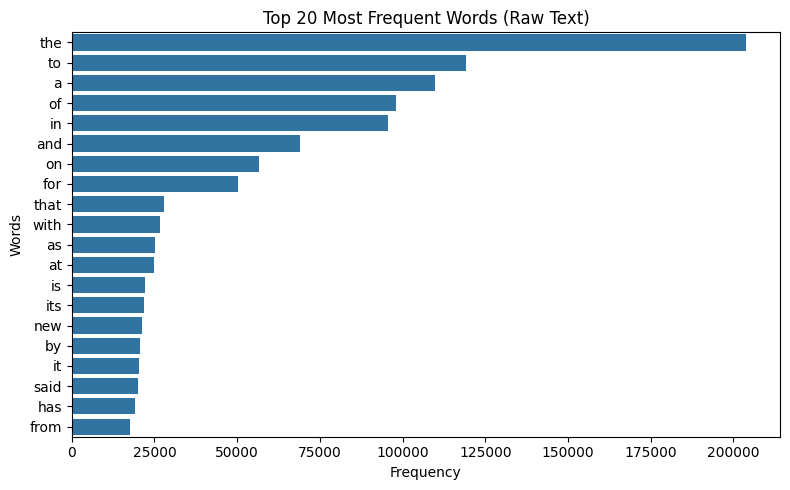

In [7]:
# visualization 3: 20 most frequent words
all_raw_text = " ".join(df["Text"].tolist())  # join all text data into a single string
tokens_raw = word_tokenize(all_raw_text)  # tokenize raw text
tokens_raw = [word.lower() for word in tokens_raw if word.isalpha()]  # alphabetic words and lowercased
tokens_raw = [word for word in tokens_raw if word != 's']
token_freq_raw = Counter(tokens_raw)  # frequency
common_tokens_raw = token_freq_raw.most_common(20)
words_raw, freqs_raw = zip(*common_tokens_raw)

plt.figure(figsize=(8,5))
sns.barplot(x=list(freqs_raw), y=list(words_raw))
plt.title("Top 20 Most Frequent Words (Raw Text)")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.tight_layout()
plt.show()

3. Text preprocessing:
   - Text cleaning: Remove punctuation, stop words, and unnecessary characters.
   - Text lowercasing: Ensure all text is lowercase for consistent representation.
   - Tokenization: Break down the text into individual words (or tokens). Explore libraries like nltk or spaCy for tokenization functionalities. You can also use keras tokenizer or Pytorch tokenizer.
   - Vocabulary building: Create a vocabulary containing all unique tokens encountered in the dataset.
   - Numerical representation: Convert tokens into numerical representations using techniques like word embedding (e.g., Word2Vec, GloVe).

In [10]:
### ADD YOUR CODE HERE ###

# preprocessing
stop_words = set(stopwords.words('english'))

def clean_and_tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return ["[CLS]"] + tokens

df["Tokens"] = df["Text"].apply(clean_and_tokenize)


In [9]:
# load pre-trained GloVe embeddings
glove = GloVe(name='6B', dim=50)

# convert tokens to embeddings
def tokens_to_embeddings(tokens):
    embeddings = []
    for token in tokens:
        if token in glove.stoi:
            embeddings.append(glove[token])
        else:
            embeddings.append(torch.zeros(glove.dim))  # if token not in GloVe, use zero vector
    return torch.stack(embeddings)

df["Embeddings"] = df["Tokens"].apply(tokens_to_embeddings)

# convert tokens to input_ids using GloVe
def tokens_to_input_ids(tokens):
    # index 1 for the [CLS] token.
    # for other tokens, using GloVe lookup, defaulting to 0 if not found
    return [1 if token == "[CLS]" else glove.stoi.get(token, 0) for token in tokens]

df["Input_ids"] = df["Tokens"].apply(tokens_to_input_ids)

.vector_cache/glove.6B.zip: 862MB [02:38, 5.42MB/s]                           
100%|█████████▉| 399999/400000 [00:11<00:00, 36055.19it/s]


In [11]:
# custom dataset
class AGNewsDataset(Dataset):
    def __init__(self, inputs, labels):
        self.inputs = inputs
        self.labels = labels

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        # Convert input tokens to LongTensor
        return torch.tensor(self.inputs[idx], dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

# collate function with padding
def collate_fn(batch):
    texts, labels = zip(*batch)
    padded_texts = pad_sequence(texts, batch_first=True, padding_value=0)
    return padded_texts, torch.tensor(labels)

# dataset and dataLoader
dataset = AGNewsDataset(df["Embeddings"].tolist(), df["Label"].tolist())
loader = DataLoader(dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)

# sample
sample_batch = next(iter(loader))
print("Sample batch shape (inputs):", sample_batch[0].shape)
print("Sample batch shape (labels):", sample_batch[1].shape)

Sample batch shape (inputs): torch.Size([32, 35, 50])
Sample batch shape (labels): torch.Size([32])


<ipython-input-11-a04fad7eed9c>:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(self.inputs[idx], dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)


## Step 2: Model Construction

1. Embeddings and positional encoding: Define an embedding layer to map tokens into numerical vectors. If using pre-trained embeddings, ensure they are compatible with your model's input dimension.

In [12]:
### ADD YOUR CODE HERE ###
!pip install torchinfo

In [13]:
#used pre-trained embeddings
import torch
import torch.nn as nn
from torchinfo import summary
from torchtext.vocab import GloVe

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).float().unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].detach()

2. Implement the core Transformer architecture:
   - Encoder: Utilize `nn.TransformerEncoder` with multiple `nn.TransformerEncoderLayer` instances. Each layer typically comprises a multi-head self-attention mechanism, a feed-forward layer, and layer normalization.
   - Decoder: Employ `nn.TransformerDecoder` with multiple `nn.TransformerDecoderLayer` instances. These layers incorporate masked self-attention, multi-head attention over the encoder outputs, and a feed-forward layer with layer normalization.

3. Depending on your task (e.g., classification, sequence generation), define an appropriate output layer. For classification tasks, you might use a linear layer with a softmax activation function. Additionally, for classification and regression related tasks, the decoder can be removed completely. Auto-regressive sequence generation requires a decoder.

In [57]:
### ADD YOUR CODE HERE ###
#transformer architecture and output layer
class TransformerModel(nn.Module):
    def __init__(self, input_dim, embedding_dim, n_heads, n_layers, hidden_dim, n_classes, dropout=0.1):
        super(TransformerModel, self).__init__()
        # Pre-trained GloVe embeddings
        self.embedding = nn.Embedding.from_pretrained(glove.vectors, freeze=False)
        self.positional_encoding = PositionalEncoding(d_model=embedding_dim)

        # transformer EncoderLayer and encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model=embedding_dim,
                                                    nhead=n_heads,
                                                    dim_feedforward=hidden_dim,
                                                    dropout=dropout,
                                                    batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.fc = nn.Linear(embedding_dim, n_classes)

    def forward(self, x):
        x = self.embedding(x)
        x = self.positional_encoding(x)
        x = self.transformer_encoder(x)
        x = x[:, 0, :]
        x = self.fc(x)
        return x  # no softmax here since CrossEntropyLoss expects raw logits, CrossEntropyLoss applies softmax internally

#no decoder since this is a classification task

4.	Print model summary using torchinfo.summary

In [19]:
### ADD YOUR CODE HERE ###
# load pre-trained GloVe embeddings
glove = GloVe(name='6B', dim=50)


model = TransformerModel(input_dim=len(glove.vectors),
                         embedding_dim=50,
                         n_heads=2,
                         n_layers=2,
                         hidden_dim=128,
                         n_classes=4)

dummy_input = torch.randint(0, len(glove.vectors), (32, 33), dtype=torch.long)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
dummy_input = dummy_input.to(device)

# model summary
summary(model, input_data=dummy_input)

Layer (type:depth-idx)                        Output Shape              Param #
TransformerModel                              [32, 4]                   --
├─Embedding: 1-1                              [32, 33, 50]              20,000,000
├─PositionalEncoding: 1-2                     [32, 33, 50]              --
├─TransformerEncoder: 1-3                     [32, 33, 50]              --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [32, 33, 50]              23,378
│    │    └─TransformerEncoderLayer: 3-2      [32, 33, 50]              23,378
├─Linear: 1-4                                 [32, 4]                   204
Total params: 20,046,960
Trainable params: 20,046,960
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 640.01
Input size (MB): 0.01
Forward/backward pass size (MB): 0.42
Params size (MB): 80.00
Estimated Total Size (MB): 80.43

5. Briefly describe the Transformer architecture you have defined.

<span style='color:green'>### YOUR ANSWER ###


*   The model is a Transformer-based architecture for text classification.
*   It uses pre-trained GloVe embeddings for input words.


*   Uses positional encoding to retain sequence information.
*   Embedding layer is initialized with GloVe word vectors.


*   Positional encoding gives information about word positions within the sequence to the embeddings.

*   Transformer encoder: Composed of multiple stacked nn.TransformerEncoderLayer modules, each featuring multi-head self-attention and feedforward sublayers.



*   Output layer: A fully connected layer that projects the encoded representation to the output class logits.








</span>

## Step 3: Training the Transformer

1. Preparing for training:
   - Divide the preprocessed data into training, validation, and testing sets using a common split ratio (e.g., 70:15:15 or 80:10:10).
   - Choose an appropriate loss function (e.g., cross-entropy loss for classification) and an optimizer (e.g., Adam) to update model parameters during training.

In [20]:
### ADD YOUR CODE HERE ###
import copy

class EarlyStopping:
    def __init__(self, patience=3, delta=0.0):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_loss = None
        self.best_model = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.best_model = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def load_best_model(self, model):
        model.load_state_dict(self.best_model)

In [24]:
from sklearn.model_selection import train_test_split
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

#loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

early_stopping = EarlyStopping(patience=3)

# split data into training, validation, and test sets (80:10:10)
train_data, temp_data = train_test_split(df, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)


# custom datasets
class AGNewsDataset(Dataset):
    def __init__(self, inputs, labels):
        self.inputs = inputs
        self.labels = labels

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return torch.tensor(self.inputs[idx]), torch.tensor(self.labels[idx])

train_dataset = AGNewsDataset(train_data["Input_ids"].tolist(), train_data["Label"].tolist())
val_dataset = AGNewsDataset(val_data["Input_ids"].tolist(), val_data["Label"].tolist())
test_dataset = AGNewsDataset(test_data["Input_ids"].tolist(), test_data["Label"].tolist())

# dataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

2. Define a training loop. E.g. forward pass, calculate loss, backward pass, update parameters. Train the model.

## Step 4: Evaluation and Optimization

1. Check your model's performance on the validation set. Monitor metrics like accuracy or loss to track progress. Explore at least 3 optimization techniques to improve the performance of your Transformer model. E.g. regularization (L1/L2), dropout, early stopping, learning rate tuning.

In [25]:
### ADD YOUR CODE HERE ###
#training loop and evaluation/optimization
from sklearn.metrics import precision_recall_fscore_support, roc_curve, auc
from sklearn.preprocessing import label_binarize

# for evaluation
train_accuracies = []
train_losses = []
val_accuracies = []
val_losses = []
test_accuracies = []
test_losses = []

# for precision, recall, and f1 score
all_train_labels = []
all_train_preds = []
all_val_labels = []
all_val_preds = []
all_test_labels = []
all_test_preds = []

In [26]:
# training Loop
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for batch in train_loader:
        inputs, labels = batch
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    scheduler.step()

    train_accuracy = 100 * correct_train / total_train
    train_loss = running_loss / len(train_loader)
    train_accuracies.append(train_accuracy)
    train_losses.append(train_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {train_loss:.4f}, Training Accuracy: {train_accuracy:.2f}%")

    # validation
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():  #
        for batch in val_loader:
            inputs, labels = batch
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_accuracy = 100 * correct_val / total_val
    val_loss = val_loss / len(val_loader)
    val_accuracies.append(val_accuracy)
    val_losses.append(val_loss)
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.2f}%")

    #early stopping
    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("Early stopping triggered.")
        break

Epoch 1/20, Loss: 0.3287, Training Accuracy: 88.56%
Validation Loss: 0.2784
Validation Accuracy: 90.42%
Epoch 2/20, Loss: 0.2424, Training Accuracy: 91.82%
Validation Loss: 0.2511
Validation Accuracy: 91.63%
Epoch 3/20, Loss: 0.2028, Training Accuracy: 93.12%
Validation Loss: 0.2467
Validation Accuracy: 91.72%
Epoch 4/20, Loss: 0.1717, Training Accuracy: 94.11%
Validation Loss: 0.2468
Validation Accuracy: 91.83%
Epoch 5/20, Loss: 0.1468, Training Accuracy: 94.96%
Validation Loss: 0.2535
Validation Accuracy: 91.57%
Epoch 6/20, Loss: 0.1153, Training Accuracy: 96.10%
Validation Loss: 0.2812
Validation Accuracy: 91.70%
Early stopping triggered.


In [31]:
!pip install numpy
!pip install --upgrade numpy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 99.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.4 which is incompatible.
torchvision 0.21.0+cu124 requires torch==2.6.0, but you have torch 2.2.0 which is incompatible.


In [41]:
# testing
model.eval()
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for batch in test_loader:
        inputs, labels = batch
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_test_labels.extend(labels.cpu().tolist())
        all_test_preds.extend(predicted.cpu().tolist())


test_accuracy = 100 * correct / total
test_loss = test_loss / len(test_loader)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")


Test Loss: 0.2823
Test Accuracy: 91.49%


2. Discuss how the optimization techniques helped to improve the performance of the model.

<span style='color:green'>### YOUR ANSWER ###


*   Implemented early stopping which helped prevent overfitting improving final validation and test accuracy to 91.70% and 91.49% respectively


*   Implemented StepLR scheduler to auto adjust the learning rate which improved training accuracy to 96.10% and validation accuracy to 91.70%


*   Reduced learning rate from 0.01 to 0.005, test accuracy increased to 91.49%


</span>

3. Save the weights of the model that provides the best results. Check the saving and loading of models (Pytorch).

In [44]:
### ADD YOUR CODE HERE ###
torch.save(model.state_dict(), 'best_model.pth')  # Save model manually
print("Model saved to best_model.pth")

Model saved to best_model.pth


4. Discuss the results and provide the following graphs:

   a. Training accuracy, training loss, validation accuracy, validation loss, testing accuracy, and testing loss. Provide your short analysis.

Training Performance:
Training loss consistently decreased and training accuracy increased over epochs, reaching 96.10%,  indicating that the model learned well on training data.

Validation Performance:
Validation accuracy peaked early (91.83% at epoch 4), but did not improve further despite increasing training accuracy. Validation loss started increasing slightly, signaling overfitting, after which early stopping was correctly triggered after epoch 6.

Test Performance:
The final test accuracy of 91.49% confirms good generalization and is close to validation accuracy, showing the effectiveness of early stopping and learning rate tuning.

b. Plot the training and validation accuracy over time (epochs).

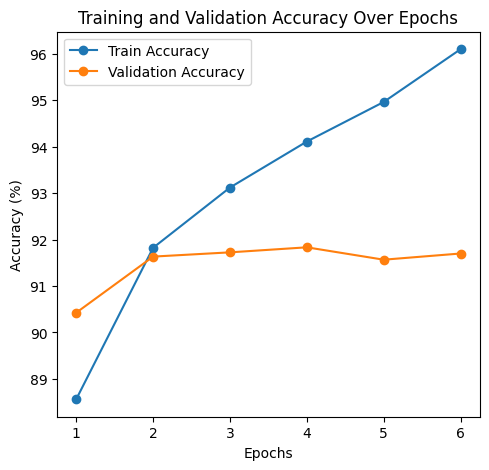

In [45]:
### ADD YOUR CODE HERE ###
# training and validation accuracy/loss over epochs
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_accuracies)+1), train_accuracies, marker='o', label='Train Accuracy')
plt.plot(range(1, len(val_accuracies)+1), val_accuracies, marker='o', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy Over Epochs')
plt.legend()

   c. Plot the training and validation loss over time (epochs).


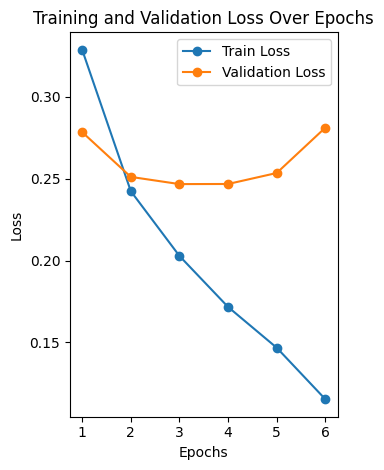

In [46]:
### ADD YOUR CODE HERE ###
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o', label='Train Loss')
plt.plot(range(1, len(val_losses)+1), val_losses, marker='o', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.tight_layout()
plt.show()

   d. Calculate and report other evaluation metrics such as Precision, recall and F1 score. You can use sklearn.metrics.precision_recall_fscore_support.


In [47]:
### ADD YOUR CODE HERE ###
#precision, recall, F1
from sklearn.metrics import precision_recall_fscore_support, roc_curve, auc
from sklearn.preprocessing import label_binarize

precision, recall, f1, _ = precision_recall_fscore_support(
    all_test_labels, all_test_preds, average='weighted'
)
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")

Test Precision: 0.9166
Test Recall: 0.9149
Test F1 Score: 0.9152


   e. Plot the ROC curve.

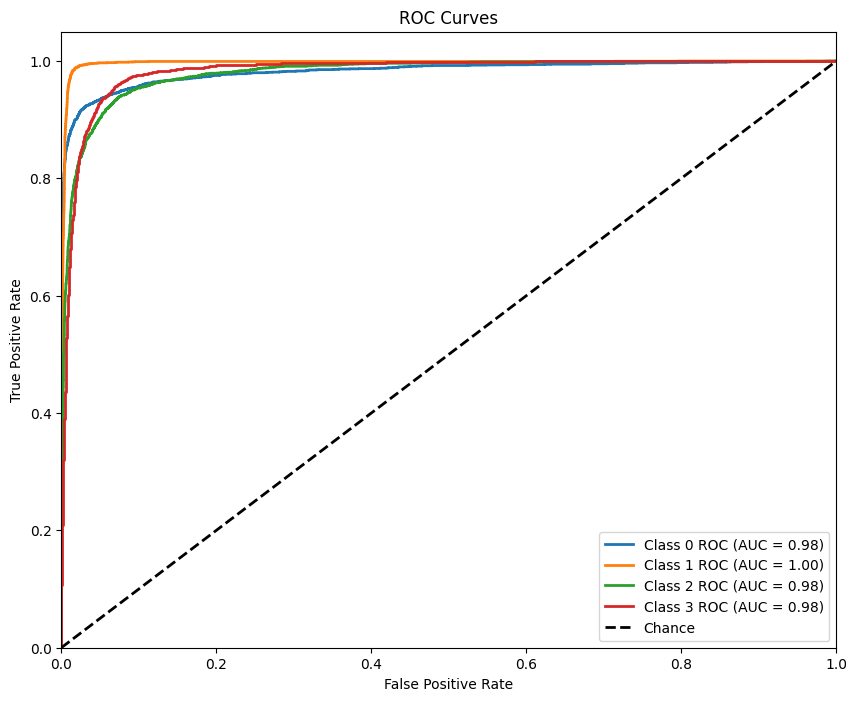

In [56]:
### ADD YOUR CODE HERE ###

all_test_labels_collected = []
all_test_probs = []
model.eval()
with torch.no_grad():
    for batch in test_loader:
        inputs, labels = batch
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        all_test_probs.extend(probs.cpu().tolist())
        all_test_labels_collected.extend(labels.cpu().tolist())


# binarize test labels for roc
all_test_labels_bin = label_binarize(all_test_labels_collected, classes=[0, 1, 2, 3])

# verify number of predictions matches the collected test labels
num_samples = len(all_test_labels_collected)
assert len(all_test_probs) == num_samples, f"Mismatch in number of samples: {len(all_test_probs)} vs {num_samples}"

# compute roc curve and auc for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(4):
    # extract probabilities for class i
    probs_class = [prob[i] for prob in all_test_probs]
    # compute roc curve for class i
    fpr[i], tpr[i], _ = roc_curve(all_test_labels_bin[:, i], probs_class)
    roc_auc[i] = auc(fpr[i], tpr[i])

# plot roc curves for each class
plt.figure(figsize=(10, 8))
for i in range(4):
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Class {i} ROC (AUC = {roc_auc[i]:.2f})')  # ADDED
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.show()


   f. [Optional] Use TensorBoard (or a similar tool, e.g. Wandb) to log the training and validation loss and accuracy over epochs, generate the charts, and attach the SVG images of the charts.

5. References. Include details on all the resources used to complete this part, e.g. links to datasets, research papers or articles, code examples or tutorials you referred.

<span style='color:green'>### YOUR ANSWER ###</span>

Dataset - [Link](https://drive.google.com/drive/u/0/folders/0Bz8a_Dbh9Qhbfll6bVpmNUtUcFdjYmF2SEpmZUZUcVNiMUw1TWN6RDV3a0JHT3kxLVhVR2M?resourcekey=0-TLwzfR2O-D2aPitmn5o9VQ)

https://github.com/Bjarten/early-stopping-pytorch

https://nlp.stanford.edu/projects/glove/

https://pytorch.org/docs/stable/generated/torch.nn.Transformer.html

https://medium.com/@bavalpreetsinghh/transformer-from-scratch-using-pytorch-28a5d1b2e033

https://pytorch.org/text/stable/vocab.html#glove


